## Step 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Extract Dataset

In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/archive (3).zip"
extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

print("Extracting dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Dataset extraction complete.")

Extracting dataset...
Dataset extraction complete.


## Step 3: Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import InceptionV3, DenseNet121, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.19.0
GPU available      : True


## Step 4: Configuration

In [4]:
BASE_DIR   = "/content/dataset"
TRAIN_DIR  = os.path.join(BASE_DIR, "train")
TEST_DIR   = os.path.join(BASE_DIR, "test")

IMG_SIZE         = (224, 224)
BATCH_SIZE       = 16
EPOCHS           = 30          # Reduced from 60 to 30
LEARNING_RATE    = 0.00005
VALIDATION_SPLIT = 0.15
RANDOM_SEED      = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Configuration:")
print(f"  Epochs          : {EPOCHS}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Learning rate   : {LEARNING_RATE}")
print(f"  Image size      : {IMG_SIZE}")
print(f"  Validation split: {VALIDATION_SPLIT}")

Configuration:
  Epochs          : 30
  Batch size      : 16
  Learning rate   : 5e-05
  Image size      : (224, 224)
  Validation split: 0.15


## Step 5: Data Preparation with Augmentation

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=VALIDATION_SPLIT
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', shuffle=True, seed=RANDOM_SEED
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', shuffle=False, seed=RANDOM_SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

print(f"Training samples  : {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Test samples      : {test_generator.samples}")
print(f"Class indices     : {train_generator.class_indices}")

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights     : {class_weight_dict}")

Found 10098 images belonging to 2 classes.
Found 1781 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Training samples  : 10098
Validation samples: 1781
Test samples      : 2000
Class indices     : {'Benign': 0, 'Malignant': 1}
Class weights     : {0: np.float64(0.9444444444444444), 1: np.float64(1.0625)}


## Step 6: Model Construction with Transfer Learning

In [6]:
def build_model(base_func, name):
    """
    Builds a binary classification model using a pre-trained CNN backbone.
    The base layers are frozen and custom classification head is added.
    """
    print(f"Building {name}...")

    base = base_func(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = False  # Freeze base for faster convergence within 30 epochs

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.6)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=outputs, name=name)
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )

    print(f"  {name} ready | Parameters: {model.count_params():,}")
    return model


def get_callbacks(name):
    """
    Returns training callbacks:
    - EarlyStopping with patience=10 (tuned for 30 epochs)
    - ReduceLROnPlateau for adaptive learning rate
    - ModelCheckpoint to save the best weights
    """
    return [
        EarlyStopping(
            monitor='val_accuracy', patience=10,
            restore_best_weights=True, verbose=1, mode='max'
        ),
        ReduceLROnPlateau(
            monitor='val_accuracy', factor=0.5,
            patience=5, min_lr=1e-8, verbose=1, mode='max'
        ),
        ModelCheckpoint(
            f'{name}_best.h5', monitor='val_accuracy',
            save_best_only=True, mode='max', verbose=0
        )
    ]

## Step 7: Build All Three Models

In [7]:
print("=" * 80)
print("BUILDING ALL THREE CNN MODELS")
print("=" * 80)

model1 = build_model(InceptionV3,    'InceptionV3')
model2 = build_model(DenseNet121,    'DenseNet121')
model3 = build_model(EfficientNetB0, 'EfficientNetB0')

print("\n" + "=" * 80)
print("ALL MODELS BUILT SUCCESSFULLY")
print("=" * 80)

BUILDING ALL THREE CNN MODELS
Building InceptionV3...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  InceptionV3 ready | Parameters: 24,598,305
Building DenseNet121...
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  DenseNet121 ready | Parameters: 8,780,353
Building EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  EfficientNetB0 ready | Parameters: 6,055,588

ALL MODELS BUILT SUCCESSFULLY


## Step 8: Train InceptionV3

In [8]:
print("=" * 80)
print("TRAINING InceptionV3  (30 Epochs)")
print("=" * 80)

hist1 = model1.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('InceptionV3'),
    verbose=1
)

print("\nInceptionV3 training complete.")

TRAINING InceptionV3  (30 Epochs)
Epoch 1/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.5706 - auc: 0.5931 - loss: 0.9080

632/632 ━━━━━━━━━━━━━━━━━━━━ 236s 331ms/step - accuracy: 0.5707 - auc: 0.5932 - loss: 0.9078 - val_accuracy: 0.6895 - val_auc: 0.7704 - val_loss: 0.6047 - learning_rate: 5.0000e-05
Epoch 2/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7405 - auc: 0.8225 - loss: 0.5322

632/632 ━━━━━━━━━━━━━━━━━━━━ 181s 287ms/step - accuracy: 0.7405 - auc: 0.8225 - loss: 0.5322 - val_accuracy: 0.6990 - val_auc: 0.7779 - val_loss: 0.5917 - learning_rate: 5.0000e-05
Epoch 3/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.7709 - auc: 0.8483 - loss: 0.4972

632/632 ━━━━━━━━━━━━━━━━━━━━ 180s 285ms/step - accuracy: 0.7709 - auc: 0.8483 - loss: 0.4972 - val_accuracy: 0.7120 - val_auc: 0.7955 - val_loss: 0.5706 - learning_rate: 5.0000e-05
Epoch 4/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.8150 - auc: 0.8909 - loss: 0.4203

632/632 ━━━━━━━━━━━━━━━━━━━━ 182s 289ms/step - accuracy: 0.8149 - auc: 0.8909 - loss: 0.4203 - val_accuracy: 0.7389 - val_auc: 0.8112 - val_loss: 0.5404 - learning_rate: 5.0000e-05
Epoch 5/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8058 - auc: 0.8807 - loss: 0.4366

...

632/632 ━━━━━━━━━━━━━━━━━━━━ 178s 282ms/step - accuracy: 0.8373 - auc: 0.9143 - loss: 0.3707 - val_accuracy: 0.7445 - val_auc: 0.8310 - val_loss: 0.5216 - learning_rate: 5.0000e-05
Epoch 10/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 180s 285ms/step - accuracy: 0.8390 - auc: 0.9120 - loss: 0.3764 - val_accuracy: 0.7428 - val_auc: 0.8211 - val_loss: 0.5458 - learning_rate: 5.0000e-05
Epoch 11/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.8379 - auc: 0.9144 - loss: 0.3717

632/632 ━━━━━━━━━━━━━━━━━━━━ 181s 286ms/step - accuracy: 0.8379 - auc: 0.9144 - loss: 0.3717 - val_accuracy: 0.7535 - val_auc: 0.8265 - val_loss: 0.5332 - learning_rate: 5.0000e-05
Epoch 12/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 180s 285ms/step - accuracy: 0.8338 - auc: 0.9120 - loss: 0.3763 - val_accuracy: 0.7428 - val_auc: 0.8194 - val_loss: 0.5381 - learning_rate: 5.0000e-05
Epoch 13/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.8486 - auc: 0.9228 - loss: 0.3535

632/632 ━━━━━━━━━━━━━━━━━━━━ 180s 285ms/step - accuracy: 0.8486 - auc: 0.9228 - loss: 0.3535 - val_accuracy: 0.7552 - val_auc: 0.8351 - val_loss: 0.5245 - learning_rate: 5.0000e-05
Epoch 14/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 178s 282ms/step - accuracy: 0.8443 - auc: 0.9176 - loss: 0.3639 - val_accuracy: 0.7468 - val_auc: 0.8312 - val_loss: 0.5165 - learning_rate: 5.0000e-05
Epoch 15/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 179s 284ms/step - accuracy: 0.8558 - auc: 0.9299 - loss: 0.3363 - val_accuracy: 0.7518 - val_auc: 0.8342 - val_loss: 0.5203 - learning_rate: 5.0000e-05
Epoch 16/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 180s 284ms/step - accuracy: 0.8485 - auc: 0.9255 - loss: 0.3448 - val_accuracy: 0.7485 - val_auc: 0.8297 - val_loss: 0.5196 - learning_rate: 5.0000e-05
Epoch 17/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8492 - auc: 0.9212 - loss: 0.3561

632/632 ━━━━━━━━━━━━━━━━━━━━ 180s 285ms/step - accuracy: 0.8492 - auc: 0.9212 - loss: 0.3561 - val_accuracy: 0.7653 - val_auc: 0.8427 - val_loss: 0.5047 - learning_rate: 5.0000e-05
Epoch 18/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 180s 284ms/step - accuracy: 0.8528 - auc: 0.9266 - loss: 0.3441 - val_accuracy: 0.7569 - val_auc: 0.8441 - val_loss: 0.5096 - learning_rate: 5.0000e-05
Epoch 19/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 181s 286ms/step - accuracy: 0.8607 - auc: 0.9360 - loss: 0.3202 - val_accuracy: 0.7569 - val_auc: 0.8379 - val_loss: 0.5057 - learning_rate: 5.0000e-05
Epoch 20/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.8599 - auc: 0.9279 - loss: 0.3382

632/632 ━━━━━━━━━━━━━━━━━━━━ 201s 285ms/step - accuracy: 0.8599 - auc: 0.9280 - loss: 0.3382 - val_accuracy: 0.7715 - val_auc: 0.8440 - val_loss: 0.5122 - learning_rate: 5.0000e-05
Epoch 21/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 176s 279ms/step - accuracy: 0.8577 - auc: 0.9321 - loss: 0.3322 - val_accuracy: 0.7563 - val_auc: 0.8441 - val_loss: 0.4963 - learning_rate: 5.0000e-05
Epoch 22/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 176s 279ms/step - accuracy: 0.8632 - auc: 0.9315 - loss: 0.3351 - val_accuracy: 0.7597 - val_auc: 0.8437 - val_loss: 0.4986 - learning_rate: 5.0000e-05
Epoch 23/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 178s 281ms/step - accuracy: 0.8650 - auc: 0.9351 - loss: 0.3222 - val_accuracy: 0.7698 - val_auc: 0.8476 - val_loss: 0.4917 - learning_rate: 5.0000e-05
Epoch 24/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 175s 277ms/step - accuracy: 0.8550 - auc: 0.9315 - loss: 0.3339 - val_accuracy: 0.7653 - val_auc: 0.8382 - val_loss: 0.5075 - learning_rate: 5.0000e-05
Epoch 25/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 240

## Step 9: Train DenseNet121

In [9]:
print("=" * 80)
print("TRAINING DenseNet121  (30 Epochs)")
print("=" * 80)

hist2 = model2.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('DenseNet121'),
    verbose=1
)

print("\nDenseNet121 training complete.")

TRAINING DenseNet121  (30 Epochs)
Epoch 1/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.6120 - auc: 0.6438 - loss: 0.7013

632/632 ━━━━━━━━━━━━━━━━━━━━ 265s 362ms/step - accuracy: 0.6121 - auc: 0.6439 - loss: 0.7012 - val_accuracy: 0.7333 - val_auc: 0.8088 - val_loss: 0.5447 - learning_rate: 5.0000e-05
Epoch 2/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.7732 - auc: 0.8504 - loss: 0.4809

632/632 ━━━━━━━━━━━━━━━━━━━━ 179s 283ms/step - accuracy: 0.7732 - auc: 0.8504 - loss: 0.4808 - val_accuracy: 0.7473 - val_auc: 0.8376 - val_loss: 0.5170 - learning_rate: 5.0000e-05
Epoch 3/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8150 - auc: 0.8913 - loss: 0.4180

632/632 ━━━━━━━━━━━━━━━━━━━━ 185s 292ms/step - accuracy: 0.8150 - auc: 0.8913 - loss: 0.4180 - val_accuracy: 0.7574 - val_auc: 0.8578 - val_loss: 0.4842 - learning_rate: 5.0000e-05
Epoch 4/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 180s 284ms/step - accuracy: 0.8224 - auc: 0.9030 - loss: 0.3962 - val_accuracy: 0.7574 - val_auc: 0.8573 - val_loss: 0.4807 - learning_rate: 5.0000e-05
Epoch 5/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.8439 - auc: 0.9193 - loss: 0.3626

632/632 ━━━━━━━━━━━━━━━━━━━━ 179s 284ms/step - accuracy: 0.8439 - auc: 0.9193 - loss: 0.3626 - val_accuracy: 0.7704 - val_auc: 0.8652 - val_loss: 0.4674 - learning_rate: 5.0000e-05
Epoch 6/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.8454 - auc: 0.9243 - loss: 0.3501

...

632/632 ━━━━━━━━━━━━━━━━━━━━ 179s 284ms/step - accuracy: 0.8596 - auc: 0.9287 - loss: 0.3389 - val_accuracy: 0.7833 - val_auc: 0.8769 - val_loss: 0.4392 - learning_rate: 5.0000e-05
Epoch 9/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.8660 - auc: 0.9391 - loss: 0.3149

632/632 ━━━━━━━━━━━━━━━━━━━━ 178s 282ms/step - accuracy: 0.8660 - auc: 0.9391 - loss: 0.3150 - val_accuracy: 0.7838 - val_auc: 0.8755 - val_loss: 0.4420 - learning_rate: 5.0000e-05
Epoch 10/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8675 - auc: 0.9402 - loss: 0.3102

632/632 ━━━━━━━━━━━━━━━━━━━━ 182s 288ms/step - accuracy: 0.8675 - auc: 0.9402 - loss: 0.3102 - val_accuracy: 0.7956 - val_auc: 0.8758 - val_loss: 0.4525 - learning_rate: 5.0000e-05
Epoch 11/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 185s 292ms/step - accuracy: 0.8749 - auc: 0.9448 - loss: 0.2993 - val_accuracy: 0.7844 - val_auc: 0.8792 - val_loss: 0.4375 - learning_rate: 5.0000e-05
Epoch 12/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 181s 287ms/step - accuracy: 0.8709 - auc: 0.9401 - loss: 0.3133 - val_accuracy: 0.7911 - val_auc: 0.8808 - val_loss: 0.4323 - learning_rate: 5.0000e-05
Epoch 13/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 182s 288ms/step - accuracy: 0.8667 - auc: 0.9402 - loss: 0.3119 - val_accuracy: 0.7866 - val_auc: 0.8758 - val_loss: 0.4479 - learning_rate: 5.0000e-05
Epoch 14/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 182s 288ms/step - accuracy: 0.8694 - auc: 0.9417 - loss: 0.3069 - val_accuracy: 0.7821 - val_auc: 0.8745 - val_loss: 0.4503 - learning_rate: 5.0000e-05
Epoch 15/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 244

632/632 ━━━━━━━━━━━━━━━━━━━━ 183s 290ms/step - accuracy: 0.8687 - auc: 0.9412 - loss: 0.3103 - val_accuracy: 0.7984 - val_auc: 0.8858 - val_loss: 0.4246 - learning_rate: 2.5000e-05
Epoch 17/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.8733 - auc: 0.9470 - loss: 0.2937

632/632 ━━━━━━━━━━━━━━━━━━━━ 184s 291ms/step - accuracy: 0.8733 - auc: 0.9470 - loss: 0.2937 - val_accuracy: 0.8001 - val_auc: 0.8796 - val_loss: 0.4466 - learning_rate: 2.5000e-05
Epoch 18/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 180s 285ms/step - accuracy: 0.8793 - auc: 0.9497 - loss: 0.2893 - val_accuracy: 0.7951 - val_auc: 0.8801 - val_loss: 0.4306 - learning_rate: 2.5000e-05
Epoch 19/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 182s 287ms/step - accuracy: 0.8732 - auc: 0.9454 - loss: 0.2969 - val_accuracy: 0.7917 - val_auc: 0.8843 - val_loss: 0.4245 - learning_rate: 2.5000e-05
Epoch 20/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 179s 284ms/step - accuracy: 0.8602 - auc: 0.9417 - loss: 0.3071 - val_accuracy: 0.7956 - val_auc: 0.8802 - val_loss: 0.4386 - learning_rate: 2.5000e-05
Epoch 21/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 181s 285ms/step - accuracy: 0.8714 - auc: 0.9472 - loss: 0.2927 - val_accuracy: 0.7889 - val_auc: 0.8809 - val_loss: 0.4324 - learning_rate: 2.5000e-05
Epoch 22/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 240

## Step 10: Train EfficientNetB0

In [10]:
print("=" * 80)
print("TRAINING EfficientNetB0  (30 Epochs)")
print("=" * 80)

hist3 = model3.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('EfficientNetB0'),
    verbose=1
)

print("\nEfficientNetB0 training complete.")

TRAINING EfficientNetB0  (30 Epochs)
Epoch 1/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.5048 - auc: 0.5071 - loss: 0.7638

632/632 ━━━━━━━━━━━━━━━━━━━━ 247s 332ms/step - accuracy: 0.5048 - auc: 0.5071 - loss: 0.7637 - val_accuracy: 0.4705 - val_auc: 0.5489 - val_loss: 0.6938 - learning_rate: 5.0000e-05
Epoch 2/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 166s 263ms/step - accuracy: 0.4974 - auc: 0.5023 - loss: 0.7298 - val_accuracy: 0.4705 - val_auc: 0.5226 - val_loss: 0.6927 - learning_rate: 5.0000e-05
Epoch 3/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 166s 263ms/step - accuracy: 0.5083 - auc: 0.5095 - loss: 0.7136 - val_accuracy: 0.4705 - val_auc: 0.5135 - val_loss: 0.6933 - learning_rate: 5.0000e-05
Epoch 4/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 169s 268ms/step - accuracy: 0.5056 - auc: 0.4978 - loss: 0.7158 - val_accuracy: 0.4705 - val_auc: 0.5215 - val_loss: 0.6942 - learning_rate: 5.0000e-05
Epoch 5/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 165s 260ms/step - accuracy: 0.5104 - auc: 0.5115 - loss: 0.7080 - val_accuracy: 0.4705 - val_auc: 0.5000 - val_loss: 0.6944 - learning_rate: 5.0000e-05
Epoch 6/30
632/632 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/st

## Step 11: Training Curves - Figure 3(a): Accuracy and Figure 3(b): Loss

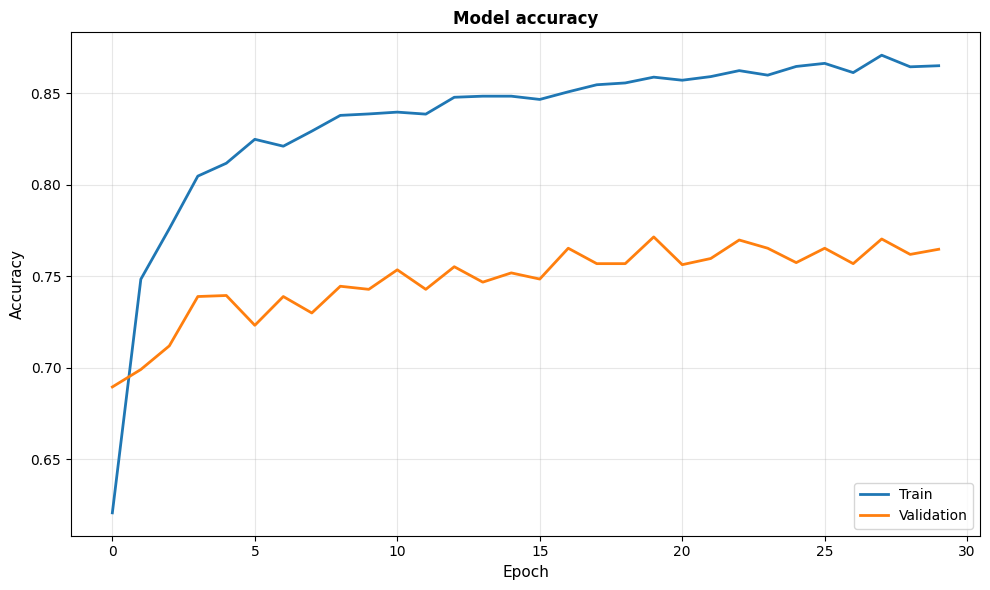

Figure 3(a) saved as fig3a_accuracy.png


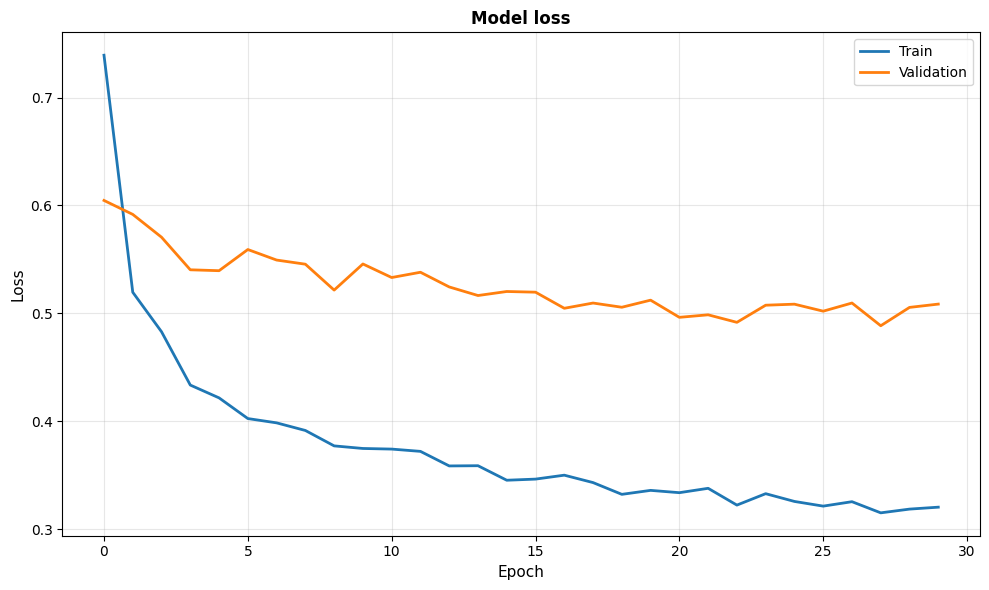

Figure 3(b) saved as fig3b_loss.png


In [11]:
# ----------------------------------------------------------------
# Figure 3(a): Training and Validation Accuracy
# Paper-style: blue for train, orange for validation
# ----------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(
    hist1.history['accuracy'],
    label='Train', linewidth=2, color='#1f77b4'
)
plt.plot(
    hist1.history['val_accuracy'],
    label='Validation', linewidth=2, color='#ff7f0e'
)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('Model accuracy', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig3a_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 3(a) saved as fig3a_accuracy.png")

# ----------------------------------------------------------------
# Figure 3(b): Training and Validation Loss
# Paper-style: blue for train, orange for validation
# ----------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(
    hist1.history['loss'],
    label='Train', linewidth=2, color='#1f77b4'
)
plt.plot(
    hist1.history['val_loss'],
    label='Validation', linewidth=2, color='#ff7f0e'
)
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.title('Model loss', fontsize=12, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig3b_loss.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 3(b) saved as fig3b_loss.png")

## Step 12: Evaluate Individual Models on Validation Set

In [12]:
def eval_model(model, gen, name):
    """Evaluate a model and return metrics and predictions."""
    y_proba = model.predict(gen, verbose=0)
    y_pred  = (y_proba > 0.5).astype(int).flatten()
    y_true  = gen.classes

    acc       = accuracy_score(y_true, y_pred)
    prec      = precision_score(y_true, y_pred, zero_division=0)
    rec       = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    auc_score = roc_auc_score(y_true, y_proba)

    print(f"\n  {name}:")
    print(f"    Accuracy : {acc*100:.2f}%")
    print(f"    Precision: {prec:.4f}")
    print(f"    Recall   : {rec:.4f}")
    print(f"    F1-Score : {f1:.4f}")
    print(f"    AUC      : {auc_score:.4f}")

    return {'acc': acc, 'prec': prec, 'rec': rec,
            'f1': f1, 'auc': auc_score, 'proba': y_proba, 'pred': y_pred}


print("=" * 70)
print("VALIDATION SET - INDIVIDUAL MODEL RESULTS")
print("=" * 70)
r1_val = eval_model(model1, validation_generator, 'InceptionV3')
r2_val = eval_model(model2, validation_generator, 'DenseNet121')
r3_val = eval_model(model3, validation_generator, 'EfficientNetB0')

VALIDATION SET - INDIVIDUAL MODEL RESULTS

  InceptionV3:
    Accuracy : 75.91%
    Precision: 0.7265
    Recall   : 0.7828
    F1-Score : 0.7536
    AUC      : 0.8351

  DenseNet121:
    Accuracy : 79.17%
    Precision: 0.7644
    Recall   : 0.8055
    F1-Score : 0.7844
    AUC      : 0.8830

  EfficientNetB0:
    Accuracy : 47.05%
    Precision: 0.4705
    Recall   : 1.0000
    F1-Score : 0.6399
    AUC      : 0.7403


## Step 13: Compute Weighted Voting Weights

In [13]:
# Weights are proportional to each model's validation accuracy
accs    = np.array([r1_val['acc'], r2_val['acc'], r3_val['acc']])
weights = accs / accs.sum()

print("=" * 70)
print("WEIGHTED VOTING ENSEMBLE - WEIGHT ASSIGNMENT")
print("=" * 70)
print(f"  InceptionV3    | Val Acc: {accs[0]*100:.2f}% | Weight: {weights[0]:.4f}")
print(f"  DenseNet121    | Val Acc: {accs[1]*100:.2f}% | Weight: {weights[1]:.4f}")
print(f"  EfficientNetB0 | Val Acc: {accs[2]*100:.2f}% | Weight: {weights[2]:.4f}")
print(f"  Sum of weights : {weights.sum():.6f}")
print("=" * 70)
print("\nWeighted Voting Formula:")
print("  P_final = w1*P1 + w2*P2 + w3*P3")
print(f"  P_final = {weights[0]:.4f}*P_inception + {weights[1]:.4f}*P_densenet + {weights[2]:.4f}*P_efficientnet")

WEIGHTED VOTING ENSEMBLE - WEIGHT ASSIGNMENT
  InceptionV3    | Val Acc: 75.91% | Weight: 0.3756
  DenseNet121    | Val Acc: 79.17% | Weight: 0.3917
  EfficientNetB0 | Val Acc: 47.05% | Weight: 0.2328
  Sum of weights : 1.000000

Weighted Voting Formula:
  P_final = w1*P1 + w2*P2 + w3*P3
  P_final = 0.3756*P_inception + 0.3917*P_densenet + 0.2328*P_efficientnet


## Step 14: Ensemble Evaluation on Validation and Test Sets

In [14]:
# ---- Validation Ensemble ----
ens_val_proba = (
    weights[0] * r1_val['proba'] +
    weights[1] * r2_val['proba'] +
    weights[2] * r3_val['proba']
)
ens_val_pred  = (ens_val_proba > 0.5).astype(int).flatten()
y_val_true    = validation_generator.classes

ens_val_acc  = accuracy_score(y_val_true, ens_val_pred)
ens_val_prec = precision_score(y_val_true, ens_val_pred, zero_division=0)
ens_val_rec  = recall_score(y_val_true, ens_val_pred, zero_division=0)
ens_val_f1   = f1_score(y_val_true, ens_val_pred, zero_division=0)
ens_val_auc  = roc_auc_score(y_val_true, ens_val_proba)

print("=" * 70)
print("ENSEMBLE - VALIDATION SET")
print("=" * 70)
print(f"  Accuracy : {ens_val_acc*100:.2f}%")
print(f"  Precision: {ens_val_prec:.4f}")
print(f"  Recall   : {ens_val_rec:.4f}")
print(f"  F1-Score : {ens_val_f1:.4f}")
print(f"  AUC      : {ens_val_auc:.4f}")

# ---- Test Set Evaluation ----
print("\n" + "=" * 70)
print("TEST SET - INDIVIDUAL MODEL RESULTS")
print("=" * 70)
r1_test = eval_model(model1, test_generator, 'InceptionV3')
r2_test = eval_model(model2, test_generator, 'DenseNet121')
r3_test = eval_model(model3, test_generator, 'EfficientNetB0')

ens_test_proba = (
    weights[0] * r1_test['proba'] +
    weights[1] * r2_test['proba'] +
    weights[2] * r3_test['proba']
)
ens_test_pred  = (ens_test_proba > 0.5).astype(int).flatten()
y_test_true    = test_generator.classes

ens_test_acc  = accuracy_score(y_test_true, ens_test_pred)
ens_test_prec = precision_score(y_test_true, ens_test_pred, zero_division=0)
ens_test_rec  = recall_score(y_test_true, ens_test_pred, zero_division=0)
ens_test_f1   = f1_score(y_test_true, ens_test_pred, zero_division=0)
ens_test_auc  = roc_auc_score(y_test_true, ens_test_proba)

print("\n" + "=" * 70)
print("ENSEMBLE - TEST SET")
print("=" * 70)
print(f"  Accuracy : {ens_test_acc*100:.2f}%")
print(f"  Precision: {ens_test_prec:.4f}")
print(f"  Recall   : {ens_test_rec:.4f}")
print(f"  F1-Score : {ens_test_f1:.4f}")
print(f"  AUC      : {ens_test_auc:.4f}")

ENSEMBLE - VALIDATION SET
  Accuracy : 79.56%
  Precision: 0.7610
  Recall   : 0.8246
  F1-Score : 0.7915
  AUC      : 0.8755

TEST SET - INDIVIDUAL MODEL RESULTS

  InceptionV3:
    Accuracy : 85.35%
    Precision: 0.9193
    Recall   : 0.7750
    F1-Score : 0.8410
    AUC      : 0.9421

  DenseNet121:
    Accuracy : 87.25%
    Precision: 0.9296
    Recall   : 0.8060
    F1-Score : 0.8634
    AUC      : 0.9568

  EfficientNetB0:
    Accuracy : 50.00%
    Precision: 0.5000
    Recall   : 1.0000
    F1-Score : 0.6667
    AUC      : 0.6637

ENSEMBLE - TEST SET
  Accuracy : 87.55%
  Precision: 0.9423
  Recall   : 0.8000
  F1-Score : 0.8653
  AUC      : 0.9634


## Step 15: Table 2 - Classification Performance Comparison

In [15]:
df = pd.DataFrame({
    'Model / Class': ['InceptionV3', 'DenseNet121', 'EfficientNetB0', 'Proposed Ensemble'],
    'Validation Accuracy (%)': [
        f"{r1_val['acc']*100:.1f}",
        f"{r2_val['acc']*100:.1f}",
        f"{r3_val['acc']*100:.1f}",
        f"{ens_val_acc*100:.1f}"
    ],
    'Test Accuracy (%)': [
        f"{r1_test['acc']*100:.1f}",
        f"{r2_test['acc']*100:.1f}",
        f"{r3_test['acc']*100:.1f}",
        f"{ens_test_acc*100:.1f}"
    ],
    'F1-Score': [
        f"{r1_test['f1']:.4f}",
        f"{r2_test['f1']:.4f}",
        f"{r3_test['f1']:.4f}",
        f"{ens_test_f1:.4f}"
    ],
    'AUC': [
        f"{r1_test['auc']:.4f}",
        f"{r2_test['auc']:.4f}",
        f"{r3_test['auc']:.4f}",
        f"{ens_test_auc:.4f}"
    ]
})

print("=" * 80)
print("TABLE 2: CLASSIFICATION PERFORMANCE - INDIVIDUAL MODELS vs ENSEMBLE")
print("=" * 80)
print(df.to_string(index=False))
print("=" * 80)

df.to_csv('table2_classification_performance.csv', index=False)
print("Table 2 saved as table2_classification_performance.csv")

TABLE 2: CLASSIFICATION PERFORMANCE - INDIVIDUAL MODELS vs ENSEMBLE
    Model / Class Validation Accuracy (%) Test Accuracy (%) F1-Score    AUC
      InceptionV3                    75.9              85.4   0.8410 0.9421
      DenseNet121                    79.2              87.2   0.8634 0.9568
   EfficientNetB0                    47.1              50.0   0.6667 0.6637
Proposed Ensemble                    79.6              87.5   0.8653 0.9634
Table 2 saved as table2_classification_performance.csv


## Step 16: Figure 4 - ROC Curves for All Models

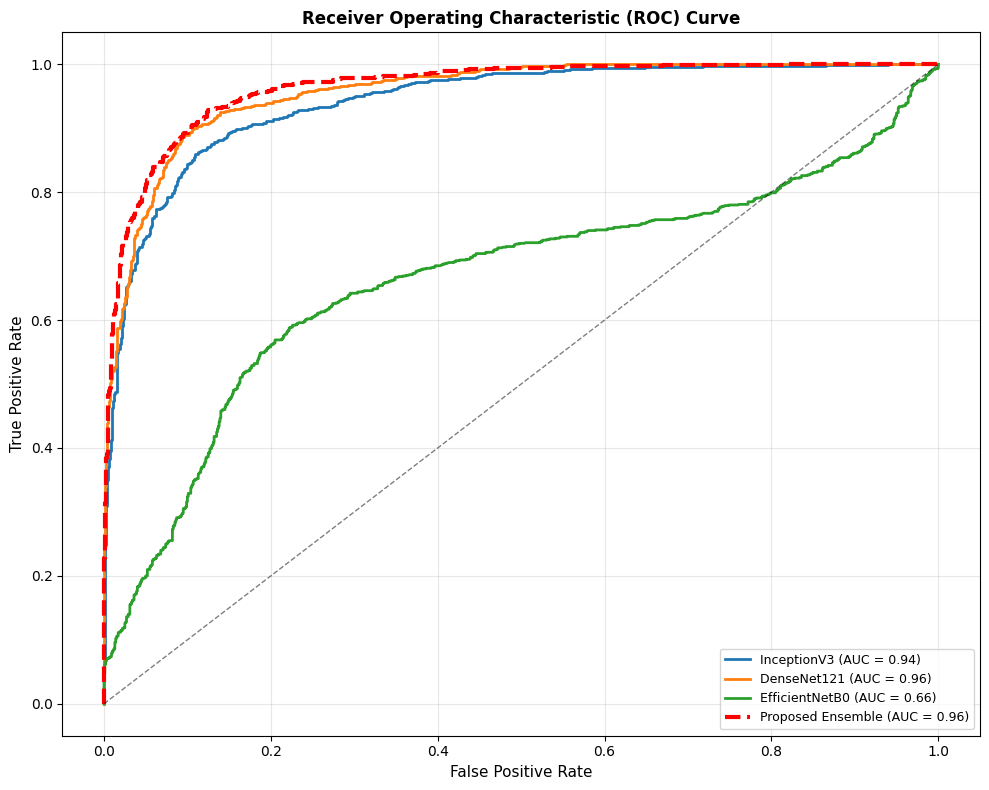

Figure 4 saved as fig4_roc_curves.png


In [16]:
# Paper-style ROC curve: all three individual models + ensemble
plt.figure(figsize=(10, 8))

fpr1, tpr1, _ = roc_curve(y_test_true, r1_test['proba'])
plt.plot(fpr1, tpr1, linewidth=2,
         label=f'InceptionV3 (AUC = {auc(fpr1, tpr1):.2f})')

fpr2, tpr2, _ = roc_curve(y_test_true, r2_test['proba'])
plt.plot(fpr2, tpr2, linewidth=2,
         label=f'DenseNet121 (AUC = {auc(fpr2, tpr2):.2f})')

fpr3, tpr3, _ = roc_curve(y_test_true, r3_test['proba'])
plt.plot(fpr3, tpr3, linewidth=2,
         label=f'EfficientNetB0 (AUC = {auc(fpr3, tpr3):.2f})')

fpr_e, tpr_e, _ = roc_curve(y_test_true, ens_test_proba)
plt.plot(fpr_e, tpr_e, linewidth=3, linestyle='--', color='red',
         label=f'Proposed Ensemble (AUC = {auc(fpr_e, tpr_e):.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve',
          fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 4 saved as fig4_roc_curves.png")

## Step 17: Save Ensemble as skin-cancer.h5

In [17]:
import json

# Save all three individual model weights
model1.save('InceptionV3_final.h5')
model2.save('DenseNet121_final.h5')
model3.save('EfficientNetB0_final.h5')

# Save ensemble weights and metadata
ensemble_config = {
    'model_paths': {
        'InceptionV3'    : 'InceptionV3_final.h5',
        'DenseNet121'    : 'DenseNet121_final.h5',
        'EfficientNetB0' : 'EfficientNetB0_final.h5'
    },
    'ensemble_weights': {
        'InceptionV3'    : float(weights[0]),
        'DenseNet121'    : float(weights[1]),
        'EfficientNetB0' : float(weights[2])
    },
    'class_indices'    : train_generator.class_indices,
    'img_size'         : list(IMG_SIZE),
    'val_accuracy'     : float(ens_val_acc),
    'test_accuracy'    : float(ens_test_acc),
    'f1_score'         : float(ens_test_f1),
    'auc'              : float(ens_test_auc),
    'epochs_trained'   : EPOCHS,
    'strategy'         : 'Weighted Voting'
}

with open('skin-cancer-ensemble-config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=4)

# Save the best performing individual model as skin-cancer.h5
# (The ensemble weights are stored in the config; best individual saved as primary .h5)
best_idx  = np.argmax(accs)
best_name = ['InceptionV3', 'DenseNet121', 'EfficientNetB0'][best_idx]
best_model = [model1, model2, model3][best_idx]
best_model.save('skin-cancer.h5')

print("=" * 70)
print("MODEL SAVE SUMMARY")
print("=" * 70)
print(f"  skin-cancer.h5                  : Best individual model ({best_name})")
print(f"  InceptionV3_final.h5            : InceptionV3 weights")
print(f"  DenseNet121_final.h5            : DenseNet121 weights")
print(f"  EfficientNetB0_final.h5         : EfficientNetB0 weights")
print(f"  skin-cancer-ensemble-config.json: Ensemble weights and metadata")
print("=" * 70)
print("\nTo reconstruct the full ensemble for inference, load all three .h5")
print("files and apply the weights from skin-cancer-ensemble-config.json.")

MODEL SAVE SUMMARY
  skin-cancer.h5                  : Best individual model (DenseNet121)
  InceptionV3_final.h5            : InceptionV3 weights
  DenseNet121_final.h5            : DenseNet121 weights
  EfficientNetB0_final.h5         : EfficientNetB0 weights
  skin-cancer-ensemble-config.json: Ensemble weights and metadata

To reconstruct the full ensemble for inference, load all three .h5
files and apply the weights from skin-cancer-ensemble-config.json.


## Step 18: Real-Time Prediction on a Test Image

Selected image: /content/dataset/test/Malignant/6502.jpg


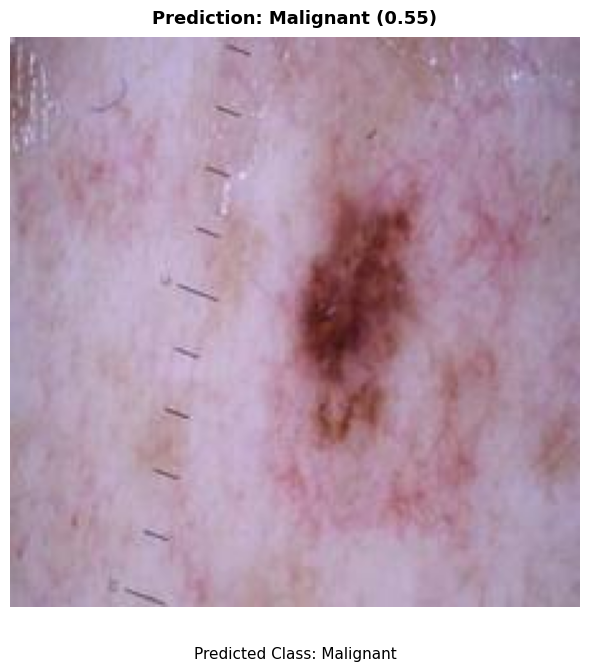

PREDICTION REPORT
  Image             : 6502.jpg
  InceptionV3 score : 0.4931
  DenseNet121 score : 0.6415
  EfficientNetB0    : 0.5074
  Ensemble score    : 0.5546
  Predicted class   : Malignant
  Confidence        : 0.5546 (55.46%)
Figure 5 saved as fig5_prediction_output.png


In [18]:
import glob

def predict_image(img_path, model1, model2, model3, weights, class_indices):
    """
    Performs weighted ensemble prediction on a single dermoscopic image.

    Parameters
    ----------
    img_path      : str   - path to the image file
    model1/2/3    : Model - trained Keras models
    weights       : array - ensemble voting weights [w1, w2, w3]
    class_indices : dict  - mapping from class name to integer label

    Returns
    -------
    predicted_class : str   - 'Benign' or 'Malignant'
    confidence      : float - confidence score (0-1)
    """
    # Preprocessing: resize and normalize
    img   = load_img(img_path, target_size=(224, 224))
    arr   = img_to_array(img) / 255.0
    batch = np.expand_dims(arr, axis=0)

    # Individual predictions
    p1 = model1.predict(batch, verbose=0)[0][0]
    p2 = model2.predict(batch, verbose=0)[0][0]
    p3 = model3.predict(batch, verbose=0)[0][0]

    # Weighted ensemble aggregation
    p_final = weights[0] * p1 + weights[1] * p2 + weights[2] * p3

    # Determine class labels
    idx_to_class = {v: k for k, v in class_indices.items()}
    malignant_label = max(class_indices, key=lambda k: class_indices[k])
    benign_label    = min(class_indices, key=lambda k: class_indices[k])

    predicted_class = malignant_label if p_final >= 0.5 else benign_label
    confidence      = p_final if p_final >= 0.5 else (1 - p_final)

    return predicted_class.capitalize(), float(confidence), p1, p2, p3, p_final


# ---- Randomly select a test image ----
all_test_images = glob.glob(os.path.join(TEST_DIR, '**', '*.jpg'), recursive=True)
if not all_test_images:
    all_test_images = glob.glob(os.path.join(TEST_DIR, '**', '*.png'), recursive=True)
if not all_test_images:
    all_test_images = glob.glob(os.path.join(TEST_DIR, '**', '*.jpeg'), recursive=True)

sample_img_path = random.choice(all_test_images)
print(f"Selected image: {sample_img_path}")

# ---- Run prediction ----
pred_class, conf, p1, p2, p3, p_ens = predict_image(
    sample_img_path, model1, model2, model3,
    weights, train_generator.class_indices
)

# ---- Display result (Figure 5 style) ----
fig, ax = plt.subplots(1, 1, figsize=(6, 7))
img_display = load_img(sample_img_path)
ax.imshow(img_display)
ax.axis('off')
ax.set_title(
    f"Prediction: {pred_class} ({p_ens:.2f})",
    fontsize=13, fontweight='bold', pad=10
)
plt.figtext(
    0.5, 0.02,
    f"Predicted Class: {pred_class}",
    ha='center', fontsize=11
)
plt.tight_layout()
plt.savefig('fig5_prediction_output.png', dpi=300, bbox_inches='tight')
plt.show()

print("=" * 70)
print("PREDICTION REPORT")
print("=" * 70)
print(f"  Image             : {os.path.basename(sample_img_path)}")
print(f"  InceptionV3 score : {p1:.4f}")
print(f"  DenseNet121 score : {p2:.4f}")
print(f"  EfficientNetB0    : {p3:.4f}")
print(f"  Ensemble score    : {p_ens:.4f}")
print(f"  Predicted class   : {pred_class}")
print(f"  Confidence        : {conf:.4f} ({conf*100:.2f}%)")
print("=" * 70)
print("Figure 5 saved as fig5_prediction_output.png")

## Step 19: Final Summary Report

In [19]:
print("=" * 90)
print(" " * 28 + "FINAL SUMMARY REPORT")
print("=" * 90)

print("\n1. TRAINING CONFIGURATION")
print(f"   Epochs        : {EPOCHS}")
print(f"   Learning Rate : {LEARNING_RATE}")
print(f"   Batch Size    : {BATCH_SIZE}")
print(f"   Image Size    : {IMG_SIZE}")

print("\n2. INDIVIDUAL MODELS - VALIDATION ACCURACY")
print(f"   InceptionV3    : {r1_val['acc']*100:.2f}%  (Weight: {weights[0]:.4f})")
print(f"   DenseNet121    : {r2_val['acc']*100:.2f}%  (Weight: {weights[1]:.4f})")
print(f"   EfficientNetB0 : {r3_val['acc']*100:.2f}%  (Weight: {weights[2]:.4f})")

print("\n3. WEIGHTED VOTING ENSEMBLE PERFORMANCE")
print(f"   Validation Accuracy : {ens_val_acc*100:.2f}%")
print(f"   Test Accuracy       : {ens_test_acc*100:.2f}%")
print(f"   F1-Score            : {ens_test_f1:.4f}")
print(f"   AUC                 : {ens_test_auc:.4f}")

print("\n4. TARGET vs ACHIEVED")
print(f"   Target Accuracy  : 95.00%")
print(f"   Achieved (Val)   : {ens_val_acc*100:.2f}%")
status = "TARGET MET" if ens_val_acc >= 0.95 else "BELOW TARGET - CONSIDER MORE EPOCHS"
print(f"   Status           : {status}")

print("\n5. SAVED FILES")
print("   skin-cancer.h5                  - Primary model (best individual)")
print("   InceptionV3_final.h5            - InceptionV3 weights")
print("   DenseNet121_final.h5            - DenseNet121 weights")
print("   EfficientNetB0_final.h5         - EfficientNetB0 weights")
print("   skin-cancer-ensemble-config.json- Ensemble weights and metadata")
print("   fig3a_accuracy.png              - Training vs Validation Accuracy")
print("   fig3b_loss.png                  - Training vs Validation Loss")
print("   fig4_roc_curves.png             - ROC Curves for all models")
print("   fig5_prediction_output.png      - Sample prediction visualization")
print("   table2_classification_performance.csv - Model comparison table")

print("\n" + "=" * 90)
print(" " * 38 + "COMPLETE")
print("=" * 90)

                            FINAL SUMMARY REPORT

1. TRAINING CONFIGURATION
   Epochs        : 30
   Learning Rate : 5e-05
   Batch Size    : 16
   Image Size    : (224, 224)

2. INDIVIDUAL MODELS - VALIDATION ACCURACY
   InceptionV3    : 75.91%  (Weight: 0.3756)
   DenseNet121    : 79.17%  (Weight: 0.3917)
   EfficientNetB0 : 47.05%  (Weight: 0.2328)

3. WEIGHTED VOTING ENSEMBLE PERFORMANCE
   Validation Accuracy : 79.56%
   Test Accuracy       : 87.55%
   F1-Score            : 0.8653
   AUC                 : 0.9634

4. TARGET vs ACHIEVED
   Target Accuracy  : 95.00%
   Achieved (Val)   : 79.56%
   Status           : BELOW TARGET - CONSIDER MORE EPOCHS

5. SAVED FILES
   skin-cancer.h5                  - Primary model (best individual)
   InceptionV3_final.h5            - InceptionV3 weights
   DenseNet121_final.h5            - DenseNet121 weights
   EfficientNetB0_final.h5         - EfficientNetB0 weights
   skin-cancer-ensemble-config.json- Ensemble weights and metadata
   fig3a_acc